# Step 3: Clustering

**Project:** Spotify Music Recommendation System
**Phase:** 3 of 4 — Clustering

## What this notebook does

In Step 2, we found that several audio features are correlated with each
other (notably energy and loudness), and that no single feature strongly
predicts a track's popularity on its own. This notebook builds on that by
asking a different question: **do songs naturally fall into groups based
on how they sound, without us telling the model anything about genre or
popularity?**

We'll use **K-Means clustering**, an unsupervised learning technique that
groups data points based purely on similarity — in our case, similarity
across the nine numerical audio features. The output of this notebook (a
fitted clustering model) also feeds directly into Step 4, where we'll use
these same audio features to power song-to-song recommendations.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
import os

sns.set_theme(style="whitegrid")
FIG_DIR = "../outputs/figures"
MODEL_DIR = "../outputs/models"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

RANDOM_STATE = 42


In [15]:
df = pd.read_csv("../data/raw/spotify_tracks.csv")
print(f"Loaded {df.shape[0]:,} tracks")


Loaded 169,909 tracks


## 3.1 Selecting features

K-Means measures distance between data points, so every feature we include
directly affects what "similar" means to the model. We use all nine core
audio features here — `acousticness`, `danceability`, `energy`,
`instrumentalness`, `liveness`, `loudness`, `speechiness`, `tempo`, and
`valence`.

One thing we confirmed in Step 2 is that `energy` and `loudness` are
fairly strongly correlated. We're keeping both anyway rather than dropping
one — they're not correlated *strongly enough* to be redundant (a track
can be loud without much energy, or vice versa), and K-Means doesn't break
down in the presence of moderate correlation the way, say, linear
regression can. We're noting it here mainly so it's clear this was a
deliberate choice, not an oversight.

In [16]:
features = [
    "acousticness", "danceability", "energy", "instrumentalness",
    "liveness", "loudness", "speechiness", "tempo", "valence",
]

X = df[features].copy()
X.describe()


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000
mean,0.493214,0.538150,0.488593,0.161937,0.206690,-11.370289,0.094058,116.948017,0.532095
std,0.376627,0.175346,0.267390,0.309329,0.176796,5.666765,0.149937,30.726937,0.262408
min,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000
25%,0.094500,0.417000,0.263000,0.000000,0.098400,-14.470000,0.034900,93.516000,0.322000
50%,0.492000,0.548000,0.481000,0.000204,0.135000,-10.474000,0.045000,114.778000,0.544000
75%,0.888000,0.667000,0.710000,0.086800,0.263000,-7.118000,0.075400,135.712000,0.749000
max,0.996000,0.988000,1.000000,1.000000,1.000000,3.855000,0.969000,244.091000,1.000000


## 3.2 Scaling the features

Look at the ranges above: `tempo` spans roughly 0–250 (beats per minute),
while `danceability` only spans 0–1. If we fed these raw values into
K-Means, `tempo` would completely dominate the distance calculations
simply because its numbers are bigger — not because it's actually more
important.

`StandardScaler` fixes this by rescaling every feature to have a mean of 0
and a standard deviation of 1, putting all nine features on equal footing
before clustering.

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (min/max):")
print(X.agg(["min", "max"]).T)
print()
print("After scaling (mean should be ~0, std should be ~1):")
print(pd.DataFrame(X_scaled, columns=features).agg(["mean", "std"]).T.round(3))


Before scaling (min/max):
                   min      max
acousticness       0.0    0.996
danceability       0.0    0.988
energy             0.0    1.000
instrumentalness   0.0    1.000
liveness           0.0    1.000
loudness         -60.0    3.855
speechiness        0.0    0.969
tempo              0.0  244.091
valence            0.0    1.000

After scaling (mean should be ~0, std should be ~1):
                  mean  std
acousticness       0.0  1.0
danceability      -0.0  1.0
energy            -0.0  1.0
instrumentalness  -0.0  1.0
liveness           0.0  1.0
loudness          -0.0  1.0
speechiness        0.0  1.0
tempo              0.0  1.0
valence           -0.0  1.0


## 3.3 How many clusters should we use?

K-Means requires us to choose the number of clusters (`k`) upfront — it
doesn't figure this out on its own. We use two standard techniques to make
an informed choice rather than guessing:

- **The elbow method**: we run K-Means for a range of `k` values and plot
  how much "error" (inertia — the sum of squared distances from each point
  to its cluster center) remains. Inertia always decreases as `k`
  increases, but we're looking for the point where adding more clusters
  stops giving us much benefit — the "elbow" in the curve.
- **Silhouette score**: a metric from -1 to 1 that measures how well-separated
  the clusters are. Higher is better. We compute this on a random sample
  of 15,000 tracks rather than the full dataset, since silhouette score is
  computationally expensive at scale.

Saved: ../outputs/figures\elbow_method.png


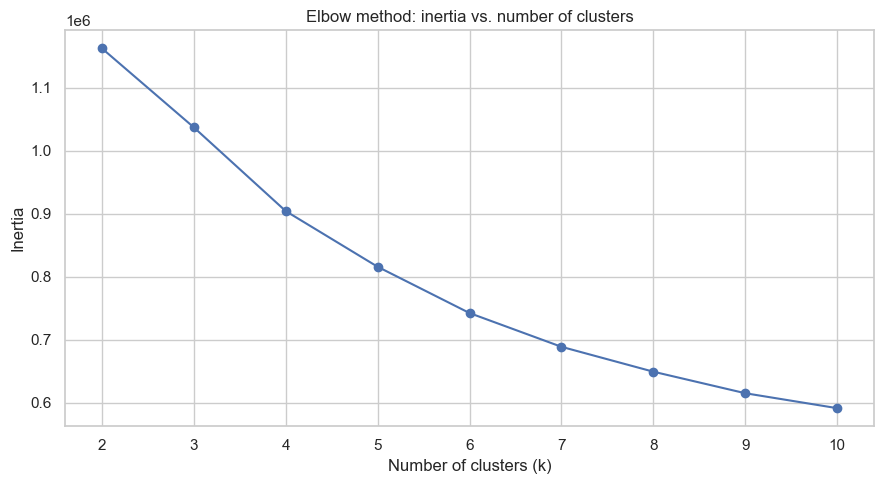

In [18]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow method: inertia vs. number of clusters")
plt.tight_layout()
save_fig(fig, "elbow_method.png")
plt.show()


In [19]:
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_scaled), 15000, replace=False)

silhouette_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_full = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled[sample_idx], labels_full[sample_idx])
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")


k=2: silhouette score = 0.2428
k=3: silhouette score = 0.2088
k=4: silhouette score = 0.2172
k=5: silhouette score = 0.1880
k=6: silhouette score = 0.1931
k=7: silhouette score = 0.1819
k=8: silhouette score = 0.1831


Saved: ../outputs/figures\silhouette_scores.png


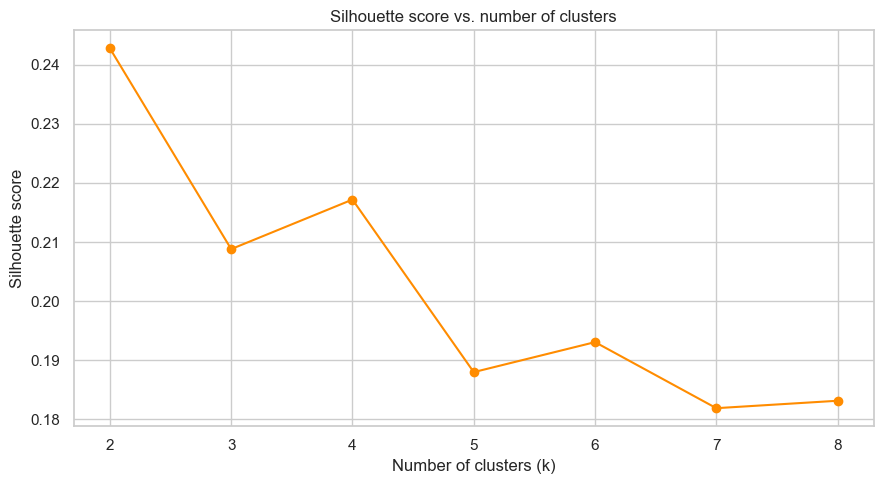

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(range(2, 9)), silhouette_scores, marker="o", color="darkorange")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score vs. number of clusters")
plt.tight_layout()
save_fig(fig, "silhouette_scores.png")
plt.show()


### Reading these results honestly

The elbow curve here doesn't have one sharp, obvious bend — it decreases
gradually across the whole range, and the silhouette scores are
consistently modest (peaking around 0.21–0.24, never approaching values
like 0.6–0.7 that would indicate crisp, well-separated clusters).

This is worth being upfront about rather than glossing over: it means
songs don't naturally fall into a small number of *sharply distinct*
sonic categories. That actually makes intuitive sense — music genuinely
exists on a continuum (a track can be "somewhat acoustic and somewhat
energetic"), rather than snapping cleanly into discrete boxes. A modest
silhouette score here isn't a failure of the method; it's an honest
reflection of what the data is actually like.

Given that, we chose **k = 6** — it sits past the steepest part of the
elbow curve (where returns start diminishing), and as we'll see below, it
produces clusters that are genuinely interpretable and musically
sensible, which matters more for this project's purpose than optimizing a
single metric.

## 3.4 Fitting the final clustering model

In [21]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts().sort_index()


cluster
0    22746
1    50885
2    43920
3    11211
4    36522
5     4625
Name: count, dtype: int64

## 3.5 What does each cluster actually represent?

Cluster numbers on their own are meaningless — the real work is looking at
each cluster's average feature values and figuring out what they represent
musically.

In [22]:
cluster_profile = df.groupby("cluster")[features].mean().round(3)
cluster_profile["avg_year"] = df.groupby("cluster")["year"].mean().round(0)
cluster_profile["n_tracks"] = df["cluster"].value_counts().sort_index()
cluster_profile


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,avg_year,n_tracks
cluster,,,,,,,,,,,
0,0.893,0.397,0.211,0.817,0.166,-18.613,0.056,105.033,0.358,1958.0,22746
1,0.327,0.696,0.616,0.060,0.154,-8.796,0.085,114.197,0.754,1986.0,50885
2,0.797,0.476,0.262,0.036,0.169,-13.896,0.056,109.520,0.411,1966.0,43920
3,0.434,0.498,0.613,0.110,0.707,-9.903,0.101,119.391,0.553,1978.0,11211
4,0.126,0.476,0.747,0.081,0.182,-7.001,0.077,137.535,0.468,1995.0,36522
5,0.514,0.670,0.262,0.013,0.320,-18.146,0.861,107.873,0.551,1947.0,4625


Saved: ../outputs/figures\cluster_feature_heatmap.png


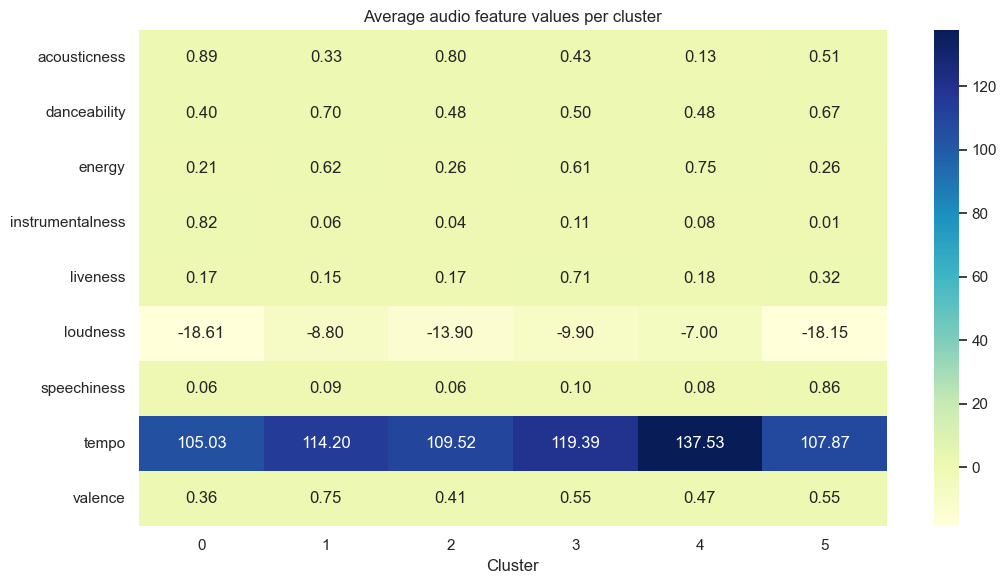

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(cluster_profile[features].T, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Average audio feature values per cluster")
ax.set_xlabel("Cluster")
plt.tight_layout()
save_fig(fig, "cluster_feature_heatmap.png")
plt.show()


### Interpreting each cluster

Based on the profile above, here's what each cluster represents, along
with representative example tracks pulled directly from the data:

- **Cluster 0 — Acoustic instrumentals**: very high acousticness (0.89)
  *and* very high instrumentalness (0.82), quiet (-18.6 dB), low energy.
  These are largely instrumental, non-electronic recordings — think
  orchestral or solo instrumental pieces. Average release year: 1958.
- **Cluster 1 — Upbeat mainstream**: high danceability (0.70), energy
  (0.62), and valence (0.75) — the classic "feel-good" pop/dance profile.
  Average release year: 1986, the most recent-skewing cluster after
  Cluster 4.
- **Cluster 2 — Mellow vocal / ballads**: high acousticness (0.80) but low
  instrumentalness (0.04), unlike Cluster 0 — meaning these are acoustic
  tracks *with* vocals, like folk or singer-songwriter ballads. Average
  release year: 1966.
- **Cluster 3 — Live recordings**: the standout feature here is liveness
  (0.71, far above every other cluster) — this cluster is picking up on
  the audience/room ambience of live performances, regardless of genre.
  Average release year: 1978.
- **Cluster 4 — High-energy / up-tempo**: lowest acousticness (0.13),
  highest energy (0.75) and tempo (137.5 BPM), and the loudest cluster
  (-7.0 dB). This reads as rock/upbeat contemporary tracks. Average
  release year: 1995, the most recent cluster.
- **Cluster 5 — Spoken word**: by far the highest speechiness (0.86,
  compared to 0.06–0.10 everywhere else) — this cluster isn't really
  "music" in the traditional sense at all. Checking example tracks
  confirms this: it's dominated by poetry readings and audiobook-style
  recordings. Average release year: 1947, the oldest cluster.

That last cluster is a good example of why it's worth actually inspecting
your clusters rather than assuming what they mean — a purely numeric
summary wouldn't have made it obvious that this cluster is arguably not
"music" at all, but the audio-feature values make total sense in
hindsight once you see it.

In [24]:
for c in sorted(df["cluster"].unique()):
    sample = df[df["cluster"] == c][["name", "artists", "year"]].sample(3, random_state=1)
    print(f"--- Cluster {c} example tracks ---")
    print(sample.to_string(index=False))
    print()


--- Cluster 0 example tracks ---
                    name             artists  year
Work / Final Rent Notice ['Charlie Chaplin']  1931
                      #7      ['Aphex Twin']  1994
                  Favela   ['Sérgio Mendes']  1966

--- Cluster 1 example tracks ---
            name                            artists  year
On And On And On                           ['ABBA']  1980
 Nadie Me Espera ['Margarita Cueto', 'Juan Arvizu']  1930
       250 Miles                   ['Radio Moscow']  2009

--- Cluster 2 example tracks ---
                       name               artists  year
       Esta Tarde Vi Llover ['Armando Manzanero']  1998
                      Needs   ['Collective Soul']  1999
Straighten up and Fly Right   ['La Vergne Smith']  1954

--- Cluster 3 example tracks ---
                  name                                           artists  year
Derdit Le Mn Reş Esmer                                   ['Hesen Zîrek']  1953
        Tell The World                         

## 3.6 Visualizing the clusters in 2D

Our data has 9 dimensions (one per audio feature), which we obviously
can't plot directly. **PCA (Principal Component Analysis)** compresses
the 9 dimensions down to 2 "components" that capture as much of the
original variation as possible, purely so we can visualize the cluster
structure. This is for visualization only — the clustering itself was
done on the full 9-dimensional data, not on this 2D projection.

Variance explained by 2 components: 49.5%
Saved: ../outputs/figures\cluster_pca_scatter.png


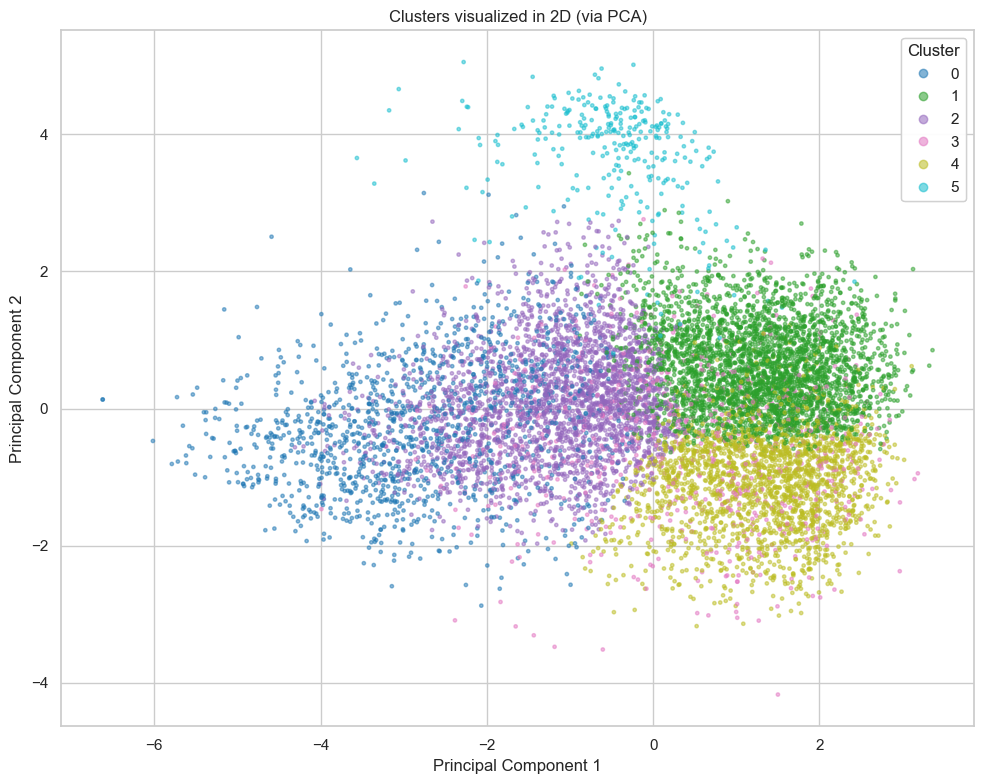

In [25]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

# Plot a random sample of 10,000 points for a readable, non-overplotted chart
np.random.seed(RANDOM_STATE)
plot_idx = np.random.choice(len(X_pca), 10000, replace=False)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca[plot_idx, 0], X_pca[plot_idx, 1],
    c=df["cluster"].values[plot_idx], cmap="tab10", s=6, alpha=0.5
)
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Clusters visualized in 2D (via PCA)")
plt.tight_layout()
save_fig(fig, "cluster_pca_scatter.png")
plt.show()


### Reading this chart

Notice the two components only capture a modest share of the original
variance (printed above) — this is consistent with what the silhouette
scores already told us: these clusters blend into each other rather than
forming tight, isolated blobs. You should still be able to see rough
regions where each color concentrates, which confirms the clusters are
capturing *real* structure — just not perfectly crisp structure, which is
an honest and expected outcome for this kind of data.

## 3.7 Saving the model

We save the fitted scaler and K-Means model so Step 4 can reuse them
without needing to retrain from scratch — both the recommendation engine
and any future app will need to transform new/query songs using this
exact same scaling.

In [26]:
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
joblib.dump(kmeans, os.path.join(MODEL_DIR, "kmeans_model.joblib"))

# Also save the clustered dataset so Step 4 doesn't need to recompute clusters
df.to_csv("../data/processed/tracks_with_clusters.csv", index=False)

print("Saved scaler, K-Means model, and clustered dataset.")


Saved scaler, K-Means model, and clustered dataset.


## Summary

- We clustered ~170,000 tracks into **6 groups** using K-Means on 9 scaled
  audio features.
- Cluster quality metrics (elbow, silhouette) were modest rather than
  sharp — an honest reflection that music exists on a continuum rather
  than falling into cleanly separated categories.
- Despite that, the resulting clusters are musically interpretable:
  acoustic instrumentals, mellow vocal ballads, upbeat mainstream tracks,
  live recordings, high-energy/up-tempo tracks, and — unexpectedly —
  spoken-word recordings that stood out clearly on the speechiness
  feature.
- The fitted scaler and clustering model are saved to
  `outputs/models/` for reuse, and the full dataset with cluster labels
  is saved to `data/processed/tracks_with_clusters.csv`.

## Next steps

Step 4 will use these same scaled audio features (and optionally the
cluster labels) to build a content-based recommendation engine: given a
song, calculate cosine similarity to every other track and return the top
10 most similar songs.
